In [25]:
%matplotlib inline
import warnings

warnings.filterwarnings("ignore") # Suppress warnings for these docs

import intake
import pandas as pd
import re
import sys
#import cosima_cookbook as cc deprecated
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import cartopy.crs as ccrs
import xarray as xr
import cmocean.cm as cmocean
import glob

import logging
logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)

from dask.distributed import Client
import matplotlib.path as mpath
import datetime as dt

In [26]:
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/34819/status,
Dashboard: /proxy/34819/status,Workers: 7
Total threads: 28,Total memory: 125.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38833,Workers: 0
Dashboard: /proxy/34819/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:42329,Total threads: 4
Dashboard: /proxy/37751/status,Memory: 17.88 GiB
Nanny: tcp://127.0.0.1:45625,


In [33]:
#https://access-nri-intake-catalog.readthedocs.io/en/latest/usage/quickstart.html
catalog = intake.cat.access_nri
#catalog_filtered = catalog.search(model="ACCESS-OM2")
#catalog_filtered

In [35]:
esm_datastore = catalog.search(name="01deg_jra55v140_iaf_cycle4").to_source()
esm_datastore.keys()

['iceh_03h_XXXX_XX_3hourly.3hr',
 'iceh_06h_XXXX_XX_6hourly.6hr',
 'iceh_XXXX_XX.1mon',
 'iceh_XXXX_XX_daily.1day',
 'ocean_2d_area_t.fx',
 'ocean_2d_area_u.fx',
 'ocean_2d_bmf_u_1_monthly_mean_ym_XXXX_XX.1mon',
 'ocean_2d_bmf_v_1_monthly_mean_ym_XXXX_XX.1mon',
 'ocean_2d_bottom_temp_1_daily_max_ym_XXXX_XX.1day',
 'ocean_2d_bottom_temp_1_daily_mean_ym_XXXX_XX.1day',
 'ocean_2d_drag_coeff.fx',
 'ocean_2d_dxt.fx',
 'ocean_2d_dxu.fx',
 'ocean_2d_dyt.fx',
 'ocean_2d_dyu.fx',
 'ocean_2d_ekman_we_1_monthly_mean_ym_XXXX_XX.1mon',
 'ocean_2d_eta_nonbouss_1_monthly_mean_ym_XXXX_XX.1mon',
 'ocean_2d_evap_1_monthly_mean_ym_XXXX_XX.1mon',
 'ocean_2d_evap_heat_1_monthly_mean_ym_XXXX_XX.1mon',
 'ocean_2d_fprec_1_monthly_mean_ym_XXXX_XX.1mon',
 'ocean_2d_fprec_melt_heat_1_monthly_mean_ym_XXXX_XX.1mon',
 'ocean_2d_frazil_3d_int_z_1_daily_mean_ym_XXXX_XX.1day',
 'ocean_2d_frazil_3d_int_z_1_monthly_mean_ym_XXXX_XX.1mon',
 'ocean_2d_geolat_c.fx',
 'ocean_2d_geolat_t.fx',
 'ocean_2d_geolon_c.fx',
 'ocean_

In [37]:
esm_datastore_filtered = esm_datastore.search(variable="surface_pot_temp")
esm_datastore_filtered.keys()

['ocean_2d_surface_pot_temp_1_daily_mean_ym_XXXX_XX.1day',
 'ocean_2d_surface_pot_temp_1_monthly_mean_ym_XXXX_XX.1mon',
 'ocean_2d_surface_pot_temp_6_hourly_mean_ym_XXXX_XX.6hr']

In [39]:
#dataset = esm_datastore_filtered.search(frequency="1mon").to_dask(progressbar=False)
dataset = esm_datastore_filtered.search(frequency="1mon").to_dask(xarray_open_kwargs={'decode_timedelta':True},progressbar=False)
dataset


<xarray.Dataset> Size: 28GB
Dimensions:           (time: 732, yt_ocean: 2700, xt_ocean: 3600, nv: 2)
Coordinates:
  * xt_ocean          (xt_ocean) float64 29kB -279.9 -279.8 ... 79.85 79.95
  * yt_ocean          (yt_ocean) float64 22kB -81.11 -81.07 ... 89.94 89.98
  * time              (time) datetime64[ns] 6kB 1958-01-16T12:00:00 ... 2018-...
  * nv                (nv) float64 16B 1.0 2.0
Data variables:
    surface_pot_temp  (time, yt_ocean, xt_ocean) float32 28GB dask.array<chunksize=(1, 540, 720), meta=np.ndarray>
    average_T1        (time) datetime64[ns] 6kB dask.array<chunksize=(1,), meta=np.ndarray>
    average_T2        (time) datetime64[ns] 6kB dask.array<chunksize=(1,), meta=np.ndarray>
    average_DT        (time) timedelta64[ns] 6kB dask.array<chunksize=(1,), meta=np.ndarray>
    time_bnds         (time, nv) timedelta64[ns] 12kB dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes: (12/14)
    title:                                    ACCESS-OM2-01
    grid_type:                                mosaic
    grid_tile:                                1
    intake_esm_vars:                          ['average_DT', 'average_T1', 'a...
    intake_esm_attrs:file_id:                 ocean_2d_surface_pot_temp_1_mon...
    intake_esm_attrs:frequency:               1mon
    ...                                       ...
    intake_esm_attrs:variable_standard_name:  ,,,,sea_surface_temperature,,,,
    intake_esm_attrs:variable_cell_methods:   ,,,,time: mean,,,,
    intake_esm_attrs:variable_units:          days,days since 1900-01-01 00:0...
    intake_esm_attrs:realm:                   ocean
    intake_esm_attrs:_data_format_:           netcdf
    intake_esm_dataset_key:                   ocean_2d_surface_pot_temp_1_mon...

In [40]:
sst=dataset.surface_pot_temp

<xarray.DataArray 'surface_pot_temp' (time: 732, yt_ocean: 2700, xt_ocean: 3600)> Size: 28GB
dask.array<concatenate, shape=(732, 2700, 3600), dtype=float32, chunksize=(1, 540, 720), chunktype=numpy.ndarray>
Coordinates:
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
  * yt_ocean  (yt_ocean) float64 22kB -81.11 -81.07 -81.02 ... 89.89 89.94 89.98
  * time      (time) datetime64[ns] 6kB 1958-01-16T12:00:00 ... 2018-12-16T12...
Attributes:
    long_name:      Potential temperature
    units:          K
    valid_range:    [-10. 500.]
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT
    standard_name:  sea_surface_temperature

In [42]:
#expt='01deg_jra55v140_iaf_cycle4_jra55v150_extension
#The mooring data is at roughly 46.7S, 142E and spans 2010->. 
#142E lon on om2 grid is 
sots_lon=-280+62
sots_lat=-46.7

start_time='2010-01-01 00:00:00'
end_time='2019-01-01 00:00:00'


In [43]:
sst=dataset.surface_pot_temp.sel(time=slice(start_time,end_time))

In [44]:
#monthly climatology of sst data
sst_clim=sst.groupby('time.month').mean('time')
#sst_clim_anom=sst.groupby("time.month") - sst_clim
sst_clim_std = sst.groupby("time.month").std("time")

In [45]:
sst_clim_sots=sst_clim.sel(yt_ocean=sots_lat, xt_ocean=sots_lon, method="nearest")

In [46]:
sst_clim_std_sots=sst_clim_std.sel(yt_ocean=sots_lat, xt_ocean=sots_lon, method="nearest")

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/flox/aggregations.py:355: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(_var_finalize(sumsq, sum_, count, ddof))
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/flox/aggregations.py:355: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(_var_finalize(sumsq, sum_, count, ddof))
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/flox/aggregations.py:355: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(_var_finalize(sumsq, sum_, count, ddof))
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/flox/aggregations.py:355: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(_var_finalize(sumsq, sum_, count, ddof))
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/flox/aggregations.py:355: RuntimeWarnin

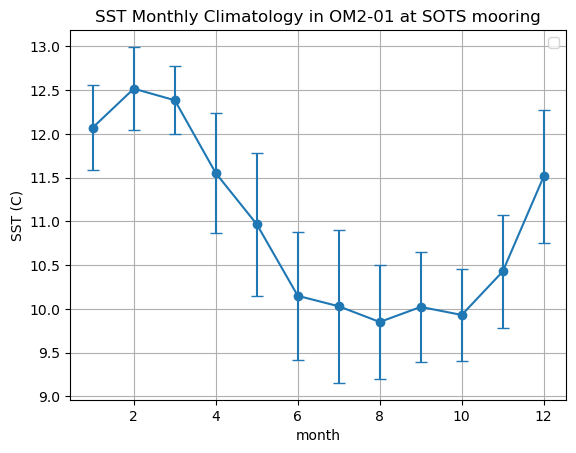

In [47]:
# Create the plot
#import matplotlib.pyplot as plt
month = list(range(1, 13))
#plt.plot(month,sst_clim_sots)

plt.errorbar(month, sst_clim_sots-273.13, yerr=sst_clim_std_sots, fmt='-o', capsize=4)


# Add labels and title
plt.xlabel("month")
plt.ylabel("SST (C)")
plt.title("SST Monthly Climatology in OM2-01 at SOTS mooring")
plt.legend()
plt.grid(True)

# Show it
plt.show()

In [11]:
#----------------------------------------------------------------------------------------------
# Function to read file and collect data for SOTS region
#----------------------------------------------------------------------------------------------

def collect_data(var, local_path, region, start_date, end_date):

    var_arr  = []

    cleaned_list = [item for item in local_path if item != []]

    
    for item,file in enumerate(cleaned_list):

        print(f'reading file: {file.split("/")[-1]}, {item+1}/{len(cleaned_list)}')
        sys.stdout.flush()
        
        with xr.open_dataset(file,decode_timedelta=False) as ds:

            time_range = ds['time'].sel(time=slice(start_date, end_date))

            data = ds[var].sel(time=time_range,\
                            yt_ocean=slice(region[0][0], region[0][1]), \
                            xt_ocean=slice(region[1][0], region[1][1])).load()
            
            data = data.mean(dim=["yt_ocean", "xt_ocean"]) 
            
    
            original_units = ds[var].attrs.get('units', '')
            
        if original_units:
            data.attrs['units'] = original_units
    
        var_arr.append(data)

    return  var_arr

In [14]:
catalog = intake.cat.access_nri

#----------------------------------------------------------------------------------------------
# Date of interest 
#----------------------------------------------------------------------------------------------

start_date = np.datetime64("2010-01-01")
end_date = np.datetime64("2023-12-31")

#----------------------------------------------------------------------------------------------
# Variable of interest in ACCESS-OM1-O1
#----------------------------------------------------------------------------------------------

var   =  'surface_pot_temp'

access_model=['01deg_jra55v140_iaf','01deg_jra55v140_iaf_cycle4_jra55v150_extension']
deg = '01deg'

#----------------------------------------------------------------------------------------------
# Variable of interest of SOTS
#----------------------------------------------------------------------------------------------

var_SOTS   =  'SST'
#----------------------------------------------------------------------------------------------
# Region of interest
#----------------------------------------------------------------------------------------------

region_lat   = np.array([-50,-45])                    # yt_ocean,N
region_lon   = np.array([145,150])                    # xt_ocean,E
region_lon   = region_lon - 360                         # -> [-213, -205]

region = [region_lat, region_lon]

#----------------------------------------------------------------------------------------------
# This section collects all the variable paths for ACCESS-OM2
#----------------------------------------------------------------------------------------------
path_dict = {var: []}

catalogs = []

for model in access_model:
    filtered = catalog[model].search(
        variable=var,
        frequency='1mon',
        realm='ocean',
    )
    catalogs.append(filtered.df)

# Concatenate the dataframes from all models
combined_df = pd.concat(catalogs, ignore_index=True)

df = combined_df[
    (combined_df['start_date'] >= '2010-01-01') &
    (combined_df['start_date'] <= '2023-12-31') &
    (combined_df['filename'].str.contains('mean'))
]


file_list = df['path'].tolist()

path_dict[var].extend(file_list)
path_dict[var].sort(key=lambda f: tuple(map(int, re.search(r'ym_(\d{4})_(\d{2})', f).groups())))


print(f'Processing {var} variable...')
sys.stdout.flush()

path_list = path_dict[var]

#----------------------------------------------------------------------------------------------
# Call function to read path and collect data
#----------------------------------------------------------------------------------------------

local_var = collect_data(var, path_list, region, start_date, end_date)

sst = xr.concat(local_var, dim='time')  # join all time together

dates = sst['time'].values

units = sst.attrs.get("units", "")

sst.attrs['units'] = units

# Get climatology
monthly_climatology = sst.groupby('time.month').mean(dim='time')

years = np.unique(sst['time.year'].values)



Processing surface_pot_temp variable...
reading file: ocean-2d-surface_pot_temp-1-monthly-mean-ym_2019_01.nc, 1/60
reading file: ocean-2d-surface_pot_temp-1-monthly-mean-ym_2019_02.nc, 2/60
reading file: ocean-2d-surface_pot_temp-1-monthly-mean-ym_2019_03.nc, 3/60
reading file: ocean-2d-surface_pot_temp-1-monthly-mean-ym_2019_04.nc, 4/60
reading file: ocean-2d-surface_pot_temp-1-monthly-mean-ym_2019_05.nc, 5/60
reading file: ocean-2d-surface_pot_temp-1-monthly-mean-ym_2019_06.nc, 6/60
reading file: ocean-2d-surface_pot_temp-1-monthly-mean-ym_2019_07.nc, 7/60
reading file: ocean-2d-surface_pot_temp-1-monthly-mean-ym_2019_08.nc, 8/60
reading file: ocean-2d-surface_pot_temp-1-monthly-mean-ym_2019_09.nc, 9/60
reading file: ocean-2d-surface_pot_temp-1-monthly-mean-ym_2019_10.nc, 10/60
reading file: ocean-2d-surface_pot_temp-1-monthly-mean-ym_2019_11.nc, 11/60
reading file: ocean-2d-surface_pot_temp-1-monthly-mean-ym_2019_12.nc, 12/60
reading file: ocean-2d-surface_pot_temp-1-monthly-mean-ym

In [15]:
sst

<xarray.DataArray 'surface_pot_temp' (time: 60)> Size: 240B
array([285.69772, 285.8604 , 285.84506, 285.46912, 285.10892, 284.47266,
       283.76575, 282.95074, 282.62393, 282.66077, 282.89865, 283.35046,
       284.39877, 285.25696, 285.0081 , 284.6623 , 283.86325, 283.33505,
       283.10455, 282.98898, 282.88214, 282.97812, 283.8587 , 284.1058 ,
       285.218  , 285.41315, 285.24292, 284.4956 , 283.76263, 283.43552,
       283.34204, 283.14746, 282.95825, 283.19733, 283.82315, 284.63742,
       286.08707, 286.7396 , 286.2159 , 285.2456 , 284.55127, 283.7254 ,
       283.35153, 283.0039 , 282.89362, 283.29242, 283.87057, 284.78302,
       286.56592, 286.34824, 285.2561 , 284.36465, 283.7336 , 283.20065,
       283.00345, 282.75665, 282.70074, 282.86667, 283.56668, 284.83682],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 480B 2019-01-16T12:00:00 ... 2023-12-16T12...
Attributes:
    units:    K

In [ ]:
#monthly climatology of sst data
sst_clim=sst.groupby('time.month').mean('time')
#sst_clim_anom=sst.groupby("time.month") - sst_clim
sst_clim_std = sst.groupby("time.month").std("time")

In [ ]:
# database for control simulation:
master_session = cc.database.create_session('/g/data/ik11/databases/cosima_master.db')

In [ ]:
from cosima_cookbook import explore
dbx = explore.DatabaseExplorer #(session=session)
dbx

In [2]:
ee = explore.ExperimentExplorer(session=master_session, experiment='01deg_jra55v140_iaf_cycle4')
ee

NameError: name 'explore' is not defined

In [6]:
#expt='01deg_jra55v140_iaf_cycle4_jra55v150_extension
#The mooring data is at roughly 46.7S, 142E and spans 2010->. 
#142E lon on om2 grid is 
sots_lon=-280+62
sots_lat=-46.7

In [7]:
#look at seasonal variability of ocean temp in om2 near SOTS.
start_time='2010-01-01 00:00:00'
end_time='2019-01-01 00:00:00'
sst=cc.querying.getvar(expt='01deg_jra55v140_iaf_cycle3', variable='surface_pot_temp', 
                          session=master_session, frequency='1 monthly',
                          attrs={'cell_methods': 'time: mean'},
                          start_time='2010-01-01 00:00:00', 
                          end_time='2019-01-01 00:00:00').sel(time=slice(start_time,end_time))


/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3

In [ ]:
sst

In [52]:
#monthly climatology of sst data
sst_clim=sst.groupby('time.month').mean('time')
#sst_clim_anom=sst.groupby("time.month") - sst_clim
sst_clim_std = sst.groupby("time.month").std("time")

In [62]:
sst_clim_sots=sst_clim.sel(yt_ocean=sots_lat, xt_ocean=sots_lon, method="nearest")

In [63]:
sst_clim_std_sots=sst_clim_std.sel(yt_ocean=sots_lat, xt_ocean=sots_lon, method="nearest")

/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/flox/aggregations.py:363: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(_var_finalize(sumsq, sum_, count, ddof))
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/flox/aggregations.py:363: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(_var_finalize(sumsq, sum_, count, ddof))
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/flox/aggregations.py:363: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(_var_finalize(sumsq, sum_, count, ddof))
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/flox/aggregations.py:363: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(_var_finalize(sumsq, sum_, count, ddof))
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/flox/aggregations.py:363: RuntimeWarnin

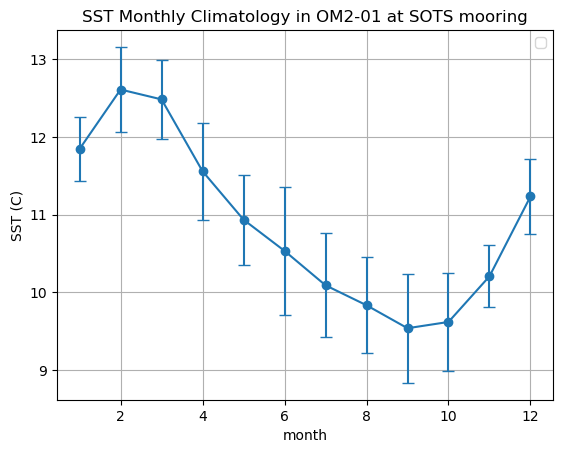

In [66]:
# Create the plot
#import matplotlib.pyplot as plt
month = list(range(1, 13))
#plt.plot(month,sst_clim_sots)

plt.errorbar(month, sst_clim_sots-273.13, yerr=sst_clim_std_sots, fmt='-o', capsize=4)


# Add labels and title
plt.xlabel("month")
plt.ylabel("SST (C)")
plt.title("SST Monthly Climatology in OM2-01 at SOTS mooring")
plt.legend()
plt.grid(True)

# Show it
plt.show()

temp=cc.querying.getvar(expt='01deg_jra55v140_iaf_cycle4', variable='temp', 
                          session=master_session, frequency='1 monthly',
                          attrs={'cell_methods': 'time: mean'},
                          start_time='1980-01-31 00:00:00', 
                          end_time='2018-12-31 00:00:00')

ax=temp[0,0,600:900,400:800].plot(vmin=275,vmax=305)
plt.plot(sots_lon, sots_lat, marker='o', color='red', markersize=6)

In [26]:
#make movies of daily SST
start_time='2010-01-01 00:00:00'
end_time='2019-01-01 00:00:00'
sst=cc.querying.getvar(expt='01deg_jra55v140_iaf_cycle3', variable='surface_pot_temp', 
                          session=master_session, frequency='1 daily',
                          attrs={'cell_methods': 'time: mean'},
                          start_time='2010-01-01 00:00:00', 
                          end_time='2019-01-01 00:00:00').sel(time=slice(start_time,end_time))

/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3

In [9]:
sst

<xarray.DataArray 'surface_pot_temp' (time: 108, yt_ocean: 2700, xt_ocean: 3600)> Size: 4GB
dask.array<getitem, shape=(108, 2700, 3600), dtype=float32, chunksize=(1, 540, 720), chunktype=numpy.ndarray>
Coordinates:
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
  * yt_ocean  (yt_ocean) float64 22kB -81.11 -81.07 -81.02 ... 89.89 89.94 89.98
  * time      (time) datetime64[ns] 864B 2010-01-16T12:00:00 ... 2018-12-16T1...
Attributes:
    long_name:      Potential temperature
    units:          K
    valid_range:    [-10. 500.]
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT
    standard_name:  sea_surface_temperature
    ncfiles:        ['/g/data/cj50/access-om2/raw-output/access-om2-01/01deg_...
    contact:        Andrew Kiss
    email:          andrew.kiss@anu.edu.au
    created:        2020-11-11
    description:    0.1 degree ACCESS-OM2 global model configuration under in...
    notes:          Run configuration and history: https://github.com/COSIMA/...

<xarray.DataArray 'surface_pot_temp' (time: 3287, yt_ocean: 2700, xt_ocean: 3600)> Size: 128GB
dask.array<getitem, shape=(3287, 2700, 3600), dtype=float32, chunksize=(1, 540, 720), chunktype=numpy.ndarray>
Coordinates:
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
  * yt_ocean  (yt_ocean) float64 22kB -81.11 -81.07 -81.02 ... 89.89 89.94 89.98
  * time      (time) datetime64[ns] 26kB 2010-01-01T12:00:00 ... 2018-12-31T1...
Attributes:
    long_name:      Potential temperature
    units:          K
    valid_range:    [-10. 500.]
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT
    standard_name:  sea_surface_temperature
    ncfiles:        ['/g/data/cj50/access-om2/raw-output/access-om2-01/01deg_...
    contact:        Andrew Kiss
    email:          andrew.kiss@anu.edu.au
    created:        2020-11-11
    description:    0.1 degree ACCESS-OM2 global model configuration under in...
    notes:          Run configuration and history: https://github.com/COSIMA/...

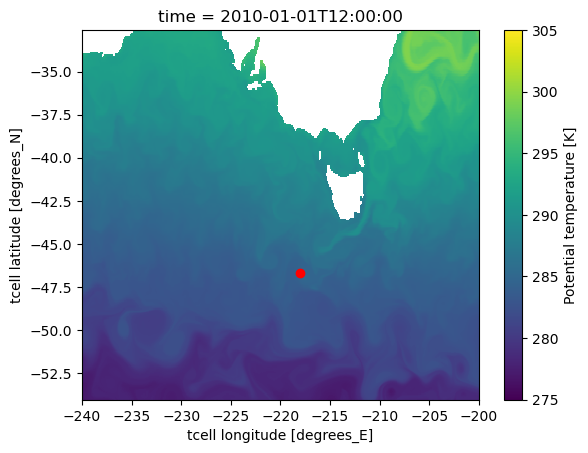

In [28]:
ax=sst[0,600:900,400:800].plot(vmin=275,vmax=305)
plt.plot(sots_lon, sots_lat, marker='o', color='red', markersize=6)

In [29]:
for ii in range(sst.time.size):
    
    filestr = '/g/data/jk72/pas561/jnb/21CW_SOTS_Ocean/om2data/sst/image%05d.png' % ii
    
    ax=sst[ii,600:900,400:800].plot(vmin=275,vmax=305)
    plt.plot(sots_lon, sots_lat, marker='o', color='red', markersize=6)
    
    plt.savefig(filestr,dpi=150)
    plt.clf()
    if np.mod(ii,10)==0:
        print(ii)

0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
210
220
230
240
250
260
270
280
290
300
310
320
330
340
350
360
370
380
390
400
410
420
430
440
450
460
470
480
490
500
510
520
530
540
550
560
570
580
590
600
610
620
630
640
650
660
670
680
690
700
710
720
730
740
750
760
770
780
790
800
810
820
830
840
850
860
870
880
890
900
910
920
930
940
950
960
970
980
990
1000
1010
1020
1030
1040
1050
1060
1070
1080
1090
1100
1110
1120
1130
1140
1150
1160
1170
1180
1190
1200
1210
1220
1230
1240
1250
1260
1270
1280
1290
1300
1310
1320
1330
1340
1350
1360
1370
1380
1390
1400
1410
1420
1430
1440
1450
1460
1470
1480
1490
1500
1510
1520
1530
1540
1550
1560
1570
1580
1590
1600
1610
1620
1630
1640
1650
1660
1670
1680
1690
1700
1710
1720
1730
1740
1750
1760
1770
1780
1790
1800
1810
1820
1830
1840
1850
1860
1870
1880
1890
1900
1910
1920
1930
1940
1950
1960
1970
1980
1990
2000
2010
2020
2030
2040
2050
2060
2070
2080
2090
2100
2110
2120
2130
2140
2150
2160
2170
2180
2190
2200
2210
2

<Figure size 640x480 with 0 Axes>

In [30]:
!ffmpeg -framerate 20 -pattern_type glob -i '/g/data/jk72/pas561/jnb/21CW_SOTS_Ocean/om2data/sst/image*.png' -s 1800x1800 -c:v libx264 -pix_fmt yuv420p /g/data/jk72/pas561/jnb/21CW_SOTS_Ocean/om2data/sst/om201_sst_daily_2010to2019.mp4

ffmpeg version 6.1.1 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 12.3.0 (conda-forge gcc 12.3.0-7)
  configuration: --prefix=/home/conda/feedstock_root/build_artifacts/ffmpeg_1716145014501/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_plac --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1716145014501/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1716145014501/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1716145014501/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1716145014501/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --disable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libo